# S&P 500 Financial Econometrics Analysis

Comprehensive statistical and econometric analysis of S&P 500 index closing prices (January 1, 2024 - May 1, 2026)


This notebook performs a rigorous financial econometric analysis of the S&P 500 index to:
1. Characterize the empirical distribution of returns
2. Test the hypothesis of normality in asset returns
3. Evaluate evidence for the Efficient Market Hypothesis (weak form)
4. Conduct variance ratio testing for the random walk hypothesis


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')


sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams.update({
    'figure.facecolor':    'none',
    'axes.facecolor':      'none',
    'savefig.facecolor':   'none',
    'savefig.transparent': True,
    'font.family':         'serif',
    'font.serif':          ['Times New Roman', 'DejaVu Serif'],
    'font.size':           11,
    'axes.labelsize':      12,
    'axes.titlesize':      14,
    'xtick.labelsize':     10,
    'ytick.labelsize':     10,
    'legend.fontsize':     10,
    'lines.linewidth':     1.5,
})

np.random.seed(42)

## 2. Download S&P 500 Data

In [2]:
#S&P 500 historical data
ticker = "^GSPC"
start_date = "2024-01-01"
end_date = "2026-05-01"
sp500_data = yf.download(ticker, start=start_date, end=end_date, progress=False)
sp500_data.head()

Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2024-01-02,4742.830078,4754.330078,4722.669922,4745.200195,3743050000
2024-01-03,4704.810059,4729.290039,4699.709961,4725.069824,3950760000
2024-01-04,4688.680176,4726.779785,4687.529785,4697.419922,3715480000
2024-01-05,4697.240234,4721.490234,4682.109863,4690.569824,3844370000
2024-01-08,4763.540039,4764.540039,4699.819824,4703.700195,3742320000


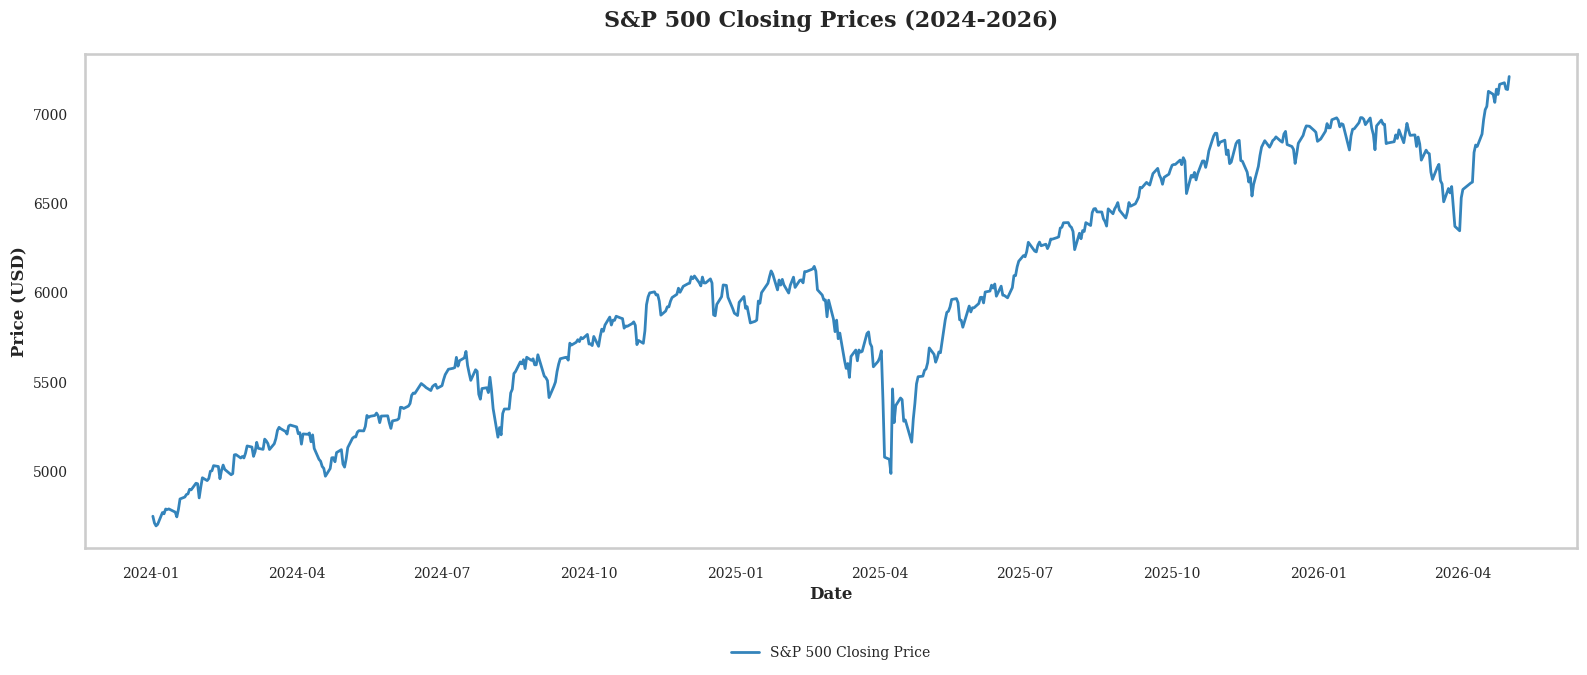

In [3]:
fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(sp500_data.index, sp500_data['Close'],
        linewidth=2, color='#1f77b4', label='S&P 500 Closing Price', alpha=0.9)
ax.set_title('S&P 500 Closing Prices (2024-2026)',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Price (USD)', fontsize=12, fontweight='bold')
ax.grid(False)
leg = ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.25),
                ncol=3, fontsize=10, frameon=False)
plt.tight_layout()
plt.show()

##3. S&P 500 Log Returns

In [4]:
sp500_data['Log_Return'] = np.log(sp500_data['Close'] / sp500_data['Close'].shift(1))
returns = sp500_data['Log_Return'].dropna()

skewness        = stats.skew(returns)
excess_kurt     = stats.kurtosis(returns, fisher=True)

print(f"\nMean (daily):           {returns.mean():.4f}")
print(f"Std (daily):            {returns.std():.4f}")
print(f"Min:                    {returns.min():.4f}")
print(f"Max:                    {returns.max():.4f}")
print(f"\nSkewness:               {skewness:+.4f}")
print(f"Excess kurtosis (Fisher): {excess_kurt:+.4f}")

returns.to_csv('log_returns.csv')



Mean (daily):           0.0007
Std (daily):            0.0099
Min:                    -0.0616
Max:                    0.0909

Skewness:               +0.3986
Excess kurtosis (Fisher): +15.4429


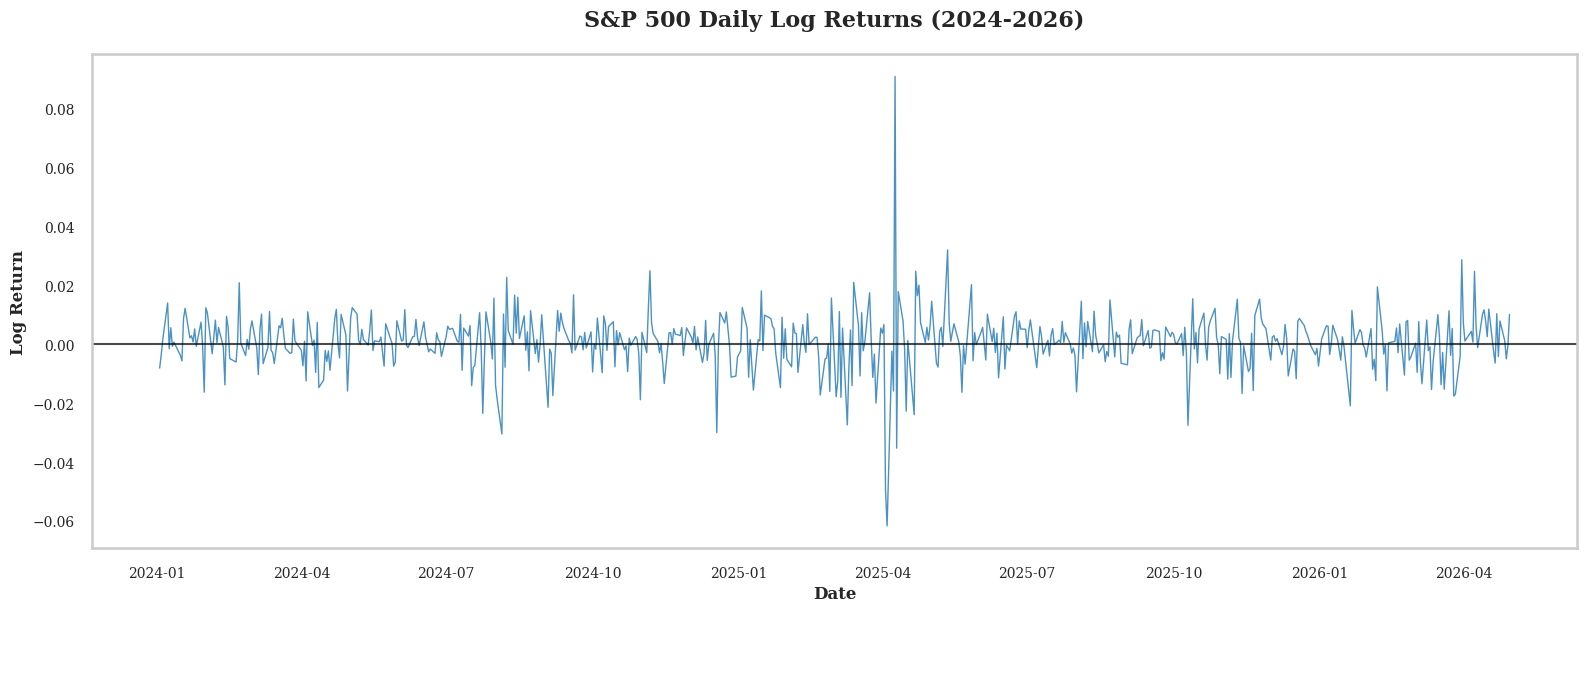

In [5]:
fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(returns.index, returns.values, linewidth=1, color='#1f77b4', alpha=0.8)
ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5, alpha=0.7)
ax.set_title('S&P 500 Daily Log Returns (2024-2026)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Log Return', fontsize=12, fontweight='bold')
ax.grid(False)
leg = ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.25),
                ncol=3, fontsize=10, frameon=False)
plt.tight_layout()
plt.show()

In [6]:
adf_result = adfuller(returns, autolag='AIC')
kpss_result = kpss(returns, regression='c', nlags='auto')

stationarity_table = pd.DataFrame({
    'Test': [
        'ADF',
        'KPSS',
    ],
    'Statistic': [
        f"{adf_result[0]:.8f}",
        f"{kpss_result[0]:.8f}",
    ],
    'P-Value': [
        f"{adf_result[1]:.8f}",
        f"{kpss_result[1]:.8f}",
    ],
    'Null Hypothesis': [
        'Unit root (non-stationary)',
        'Stationary',
    ],
    'Result': [
        'STATIONARY' if adf_result[1] < 0.05 else 'NON-STATIONARY',
        'STATIONARY' if kpss_result[1] >= 0.05 else 'NON-STATIONARY',
    ]
})

print(f"\n{stationarity_table.to_string(index=False)}")



Test    Statistic    P-Value            Null Hypothesis     Result
 ADF -13.90434511 0.00000000 Unit root (non-stationary) STATIONARY
KPSS   0.04706872 0.10000000                 Stationary STATIONARY


## 4. Distribution Analysis

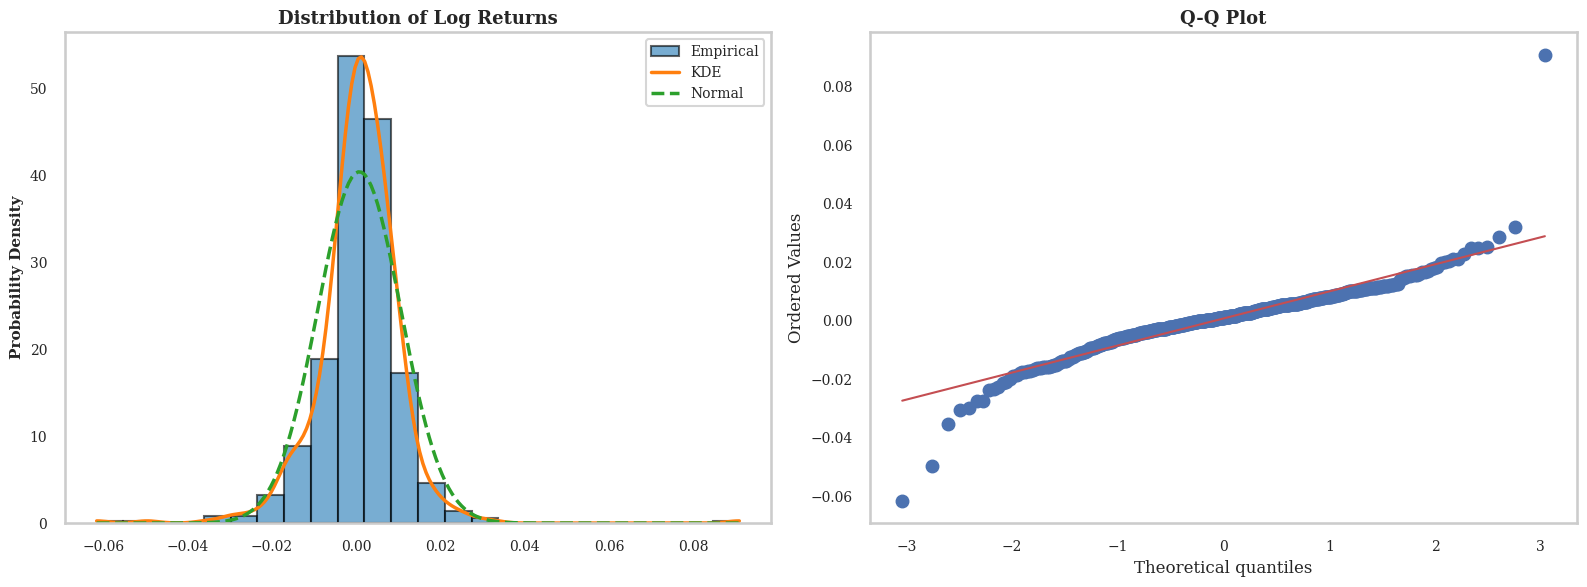

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram with KDE and normal curve
ax1 = axes[0]
ax1.hist(returns, bins=int(np.sqrt(len(returns))), density=True, alpha=0.6,
         color='#1f77b4', label='Empirical', edgecolor='black')

from scipy.stats import gaussian_kde
kde = gaussian_kde(returns)
x_range = np.linspace(returns.min(), returns.max(), 200)
ax1.plot(x_range, kde(x_range), linewidth=2.5, color='#ff7f0e', label='KDE')

mu, sigma = returns.mean(), returns.std()
ax1.plot(x_range, stats.norm.pdf(x_range, mu, sigma), linewidth=2.5,
         color='#2ca02c', label='Normal', linestyle='--')
ax1.set_title('Distribution of Log Returns', fontsize=13, fontweight='bold')
ax1.set_ylabel('Probability Density', fontsize=11, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(False)

# Q-Q Plot
ax2 = axes[1]
stats.probplot(returns, dist="norm", plot=ax2)
ax2.set_title('Q-Q Plot', fontsize=13, fontweight='bold')
ax2.grid(False)

plt.tight_layout()
plt.show()

In [8]:
returns_std = (returns - returns.mean()) / returns.std()

# Shapiro-Wilk Test
shapiro_stat, shapiro_pval = stats.shapiro(returns)

# Anderson-Darling Test
ad_result = stats.anderson(returns_std, dist='norm')
ad_stat = ad_result.statistic
ad_critical = ad_result.critical_values[2]  # 5% significance level (index 2)

# Kolmogorov-Smirnov Test
ks_stat, ks_pval = stats.kstest(returns_std, 'norm')

test_results = pd.DataFrame({
    'Test': ['Shapiro-Wilk', 'Anderson-Darling', 'Kolmogorov-Smirnov'],
    'Statistic': [f'{shapiro_stat:.6f}', f'{ad_stat:.6f}', f'{ks_stat:.6f}'],
    'P-value/Critical': [f'{shapiro_pval:.2e}', f'CV: {ad_critical:.6f}', f'{ks_pval:.2e}'],
    'Reject H₀': ['Yes' if shapiro_pval < 0.05 else 'No',
                  'Yes' if ad_stat > ad_critical else 'No',
                  'Yes' if ks_pval < 0.05 else 'No']
})

print(f"\n{test_results.to_string(index=False)}")


              Test Statistic P-value/Critical Reject H₀
      Shapiro-Wilk  0.878661         6.23e-21       Yes
  Anderson-Darling  9.773661     CV: 0.782000       Yes
Kolmogorov-Smirnov  0.093071         7.60e-05       Yes


## 5. Efficient Market Hypothesis (Weak Form)

In [9]:
#Ljung–Box on returns
print("Ljung-Box")
lb_results = []
for lag in [5, 10, 20]:
    lb_r   = acorr_ljungbox(returns,         lags=lag, return_df=True).iloc[-1]
    lb_r2  = acorr_ljungbox(returns ** 2,    lags=lag, return_df=True).iloc[-1]
    print(f"  lag={lag:>2}  returns:        Q={lb_r['lb_stat']:>8.2f}  p={lb_r['lb_pvalue']:.4f}")
    print(f"          squared returns: Q={lb_r2['lb_stat']:>8.2f}  p={lb_r2['lb_pvalue']:.4f}")
    lb_results.append({'lag': lag, 'p_returns': lb_r['lb_pvalue'], 'p_squared': lb_r2['lb_pvalue']})

#ARCH–LM test
print("ARCH-LM")
arch_results = []
for lag in [5, 10, 20]:
    arch_stat, arch_p, arch_f, arch_fp = het_arch(returns, nlags=lag)
    print(f"  lag={lag:>2}  LM={arch_stat:>8.2f}  p={arch_p:.4f}  → "
          f"{'REJECT' if arch_p < 0.05 else 'fail to reject'}")
    arch_results.append({'lag': lag, 'p': arch_p})

#Durbin Watson
print("DURBIN–WATSON")
ar_fit  = sm.OLS(returns.iloc[1:].values, sm.add_constant(returns.shift(1).dropna().values)).fit()
dw_stat = durbin_watson(ar_fit.resid)
print(f"  DW = {dw_stat:.4f} ")

#Variance Ratio Test

print("VARIANCE RATIO TEST")
print("H0: returns follow a random walk → VR(q) = 1 for all q.\n")

def variance_ratio(r, q):
    r = np.asarray(r, dtype=float)
    T = len(r)
    mu = r.mean()
    var_1 = ((r - mu) ** 2).sum() / (T - 1)
    # Overlapping q-period sums
    r_q = np.array([r[i:i+q].sum() for i in range(T - q + 1)])
    m = q * (T - q + 1) * (1 - q / T)
    var_q = ((r_q - q * mu) ** 2).sum() / m
    vr = var_q / var_1
    # Heteroskedasticity-robust z (Lo–MacKinlay eq. 17)
    delta = np.zeros(q - 1)
    centered = (r - mu) ** 2
    s2 = centered.sum()
    for j in range(1, q):
        delta[j-1] = (T * ((r[j:] - mu) * (r[:-j] - mu) * (r[j:] - mu) * (r[:-j] - mu)).sum() /
                      (s2 ** 2))
    weights = (2 * (q - np.arange(1, q)) / q) ** 2
    theta = (weights * delta).sum()
    z = (vr - 1) / np.sqrt(theta / T) if theta > 0 else np.nan
    p = 2 * (1 - stats.norm.cdf(abs(z))) if not np.isnan(z) else np.nan
    return vr, z, p

print(f"  {'q':>3} | {'VR(q)':>8} | {'z (robust)':>10} | {'p-value':>8}")
vr_results = []
for q in [2, 5, 10, 20, 30]:
    vr, z, p = variance_ratio(returns, q)
    print(f"  {q:>3} | {vr:>8.4f} | {z:>10.3f} | {p:>8.4f}")
    vr_results.append({'q': q, 'vr': vr, 'z': z, 'p': p})


# ─────────────── Summary ───────────────
print("SUMMARY")
summary = pd.DataFrame({
    'Test':       ['Ljung–Box returns (lag 20)',  'Ljung–Box squared returns (lag 20)',
                   'ARCH–LM (lag 20)',            'Durbin–Watson on AR(1) residuals',
                   'Variance Ratio (q=10)'],
    'Statistic':  [f"p={lb_results[2]['p_returns']:.4f}",  f"p={lb_results[2]['p_squared']:.4f}",
                   f"p={arch_results[2]['p']:.4f}",         f"DW={dw_stat:.4f}",
                   f"VR={vr_results[2]['vr']:.3f}, p={vr_results[2]['p']:.4f}"],
    'Verdict':    ['Reject EMH' if lb_results[2]['p_returns'] < 0.05 else 'Consistent with EMH',
                   'Volatility clustering present' if lb_results[2]['p_squared'] < 0.05 else 'No clustering',
                   'ARCH effects present' if arch_results[2]['p'] < 0.05 else 'No ARCH',
                   'Approx. no autocorr.' if 1.5 < dw_stat < 2.5 else 'Autocorrelation detected',
                   'Reject RW' if vr_results[2]['p'] < 0.05 else 'Consistent with RW'],
})
print(summary.to_string(index=False))

Ljung-Box
  lag= 5  returns:        Q=   13.97  p=0.0158
          squared returns: Q=  128.71  p=0.0000
  lag=10  returns:        Q=   17.11  p=0.0721
          squared returns: Q=  137.25  p=0.0000
  lag=20  returns:        Q=   27.34  p=0.1260
          squared returns: Q=  139.85  p=0.0000
ARCH-LM
  lag= 5  LM=   97.36  p=0.0000  → REJECT
  lag=10  LM=  109.20  p=0.0000  → REJECT
  lag=20  LM=  110.56  p=0.0000  → REJECT
DURBIN–WATSON
  DW = 1.9942 
VARIANCE RATIO TEST
H0: returns follow a random walk → VR(q) = 1 for all q.

    q |    VR(q) | z (robust) |  p-value
    2 |   0.9466 |     -0.589 |   0.5560
    5 |   0.8628 |     -0.751 |   0.4529
   10 |   0.7907 |     -0.755 |   0.4503
   20 |   0.7211 |     -0.763 |   0.4456
   30 |   0.6732 |     -0.780 |   0.4355
SUMMARY
                              Test          Statistic                       Verdict
        Ljung–Box returns (lag 20)           p=0.1260           Consistent with EMH
Ljung–Box squared returns (lag 20)         